# Assignment 12: Seaborn (Relational, Distribution, Categorical & Multi-Plots)

In [33]:
 # pip install plotly

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [35]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Task 1: Relational Plot
1. Create a relational plot (relplot) using:
o X-axis → numerical column
o Y-axis → numerical column
2. Use hue with a categorical column.
3. Create the same plot using scatter style.

Relational plot sns.relplot(kind='', data, x, y)
- Bivariate analysis
- Numerical - Numerical
- One Numerical col will change how it affects the other numerical column
- line plot - used for time series analysis - sns.lineplot()
- scatter plot - shows how 2 numberical variables are correlated sns.scatterplot()
- hue - parameter helps to segregate the data plot based on categorical column
- style - add more insight by changing style of line or dot


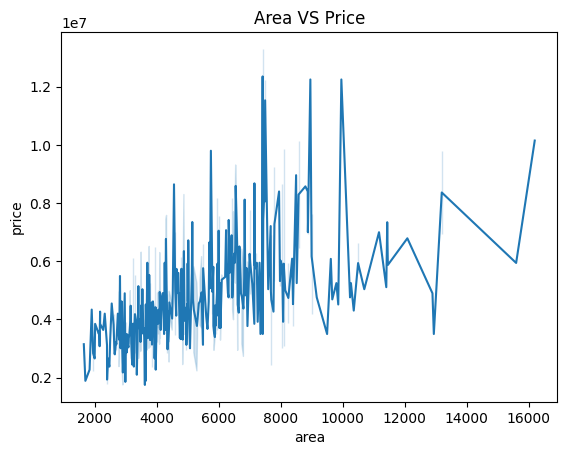

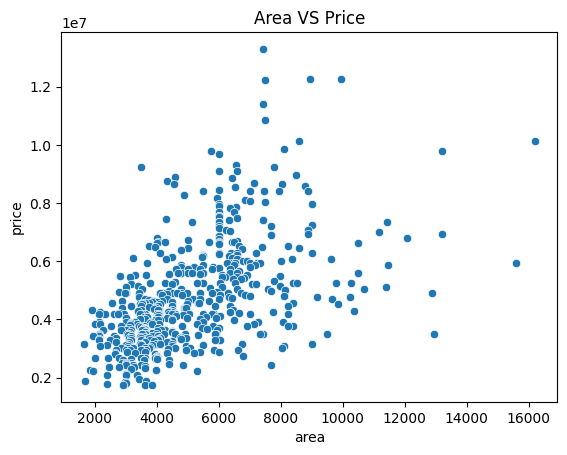

In [36]:
sns.lineplot(df, x='area', y='price', )
plt.title("Area VS Price")
plt.show()
sns.scatterplot(df, x='area', y='price', )
plt.title("Area VS Price")
plt.show()

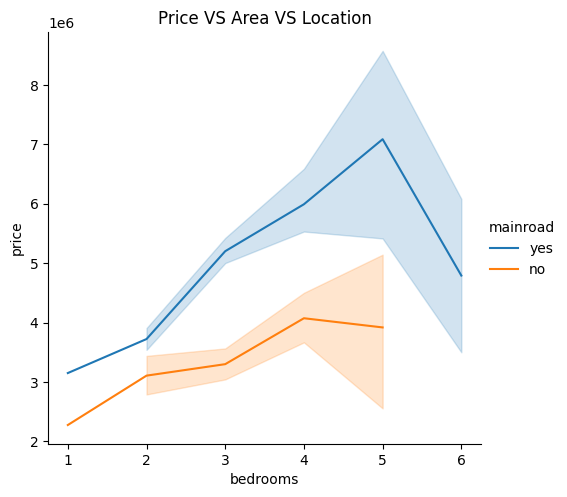

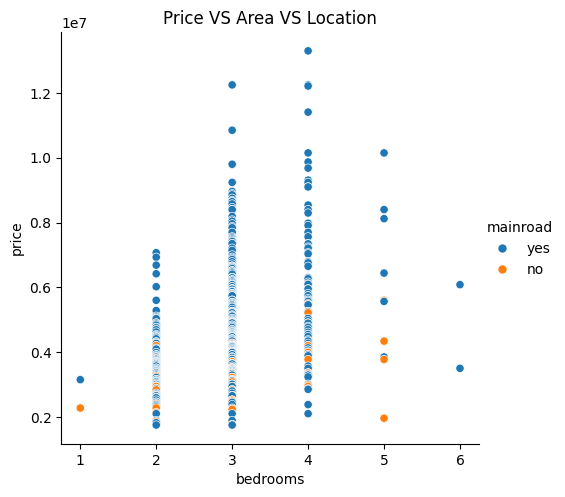

In [37]:
sns.relplot(df, x='bedrooms', y='price', kind='line', hue='mainroad')
plt.title('Price VS Area VS Location')
plt.show()

sns.relplot(df, x='bedrooms', y='price', kind='scatter', hue='mainroad')
plt.title('Price VS Area VS Location')
plt.show()


## Task 2: Line Plot as Scatter & Facet
1. Create a line plot using sns.lineplot().
2. Convert the same relationship into a scatter-style line plot.
3. Use faceting (col or row) to split the plot based on a categorical column.

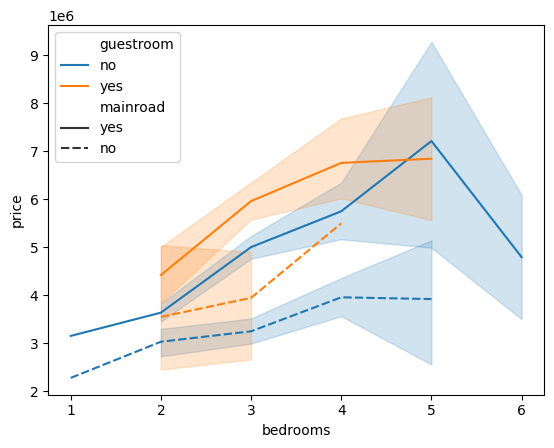

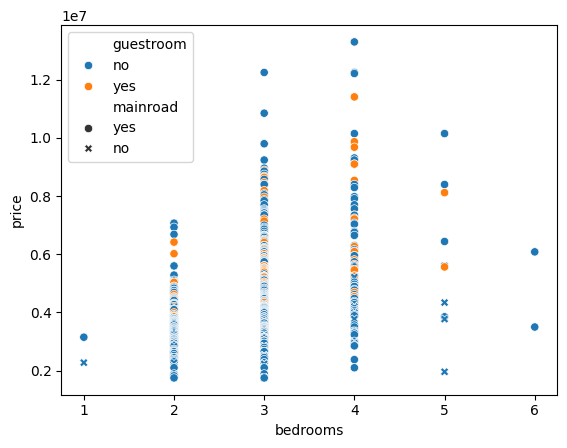

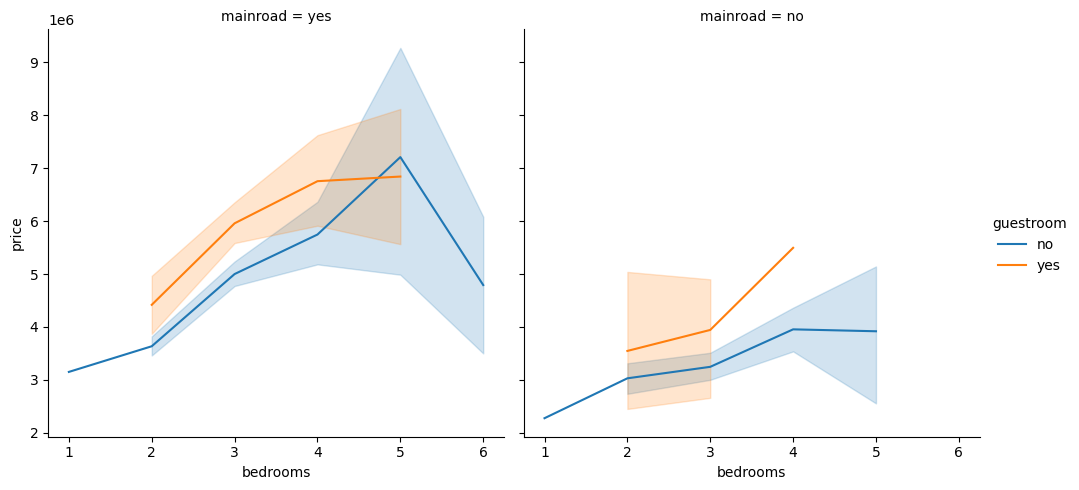

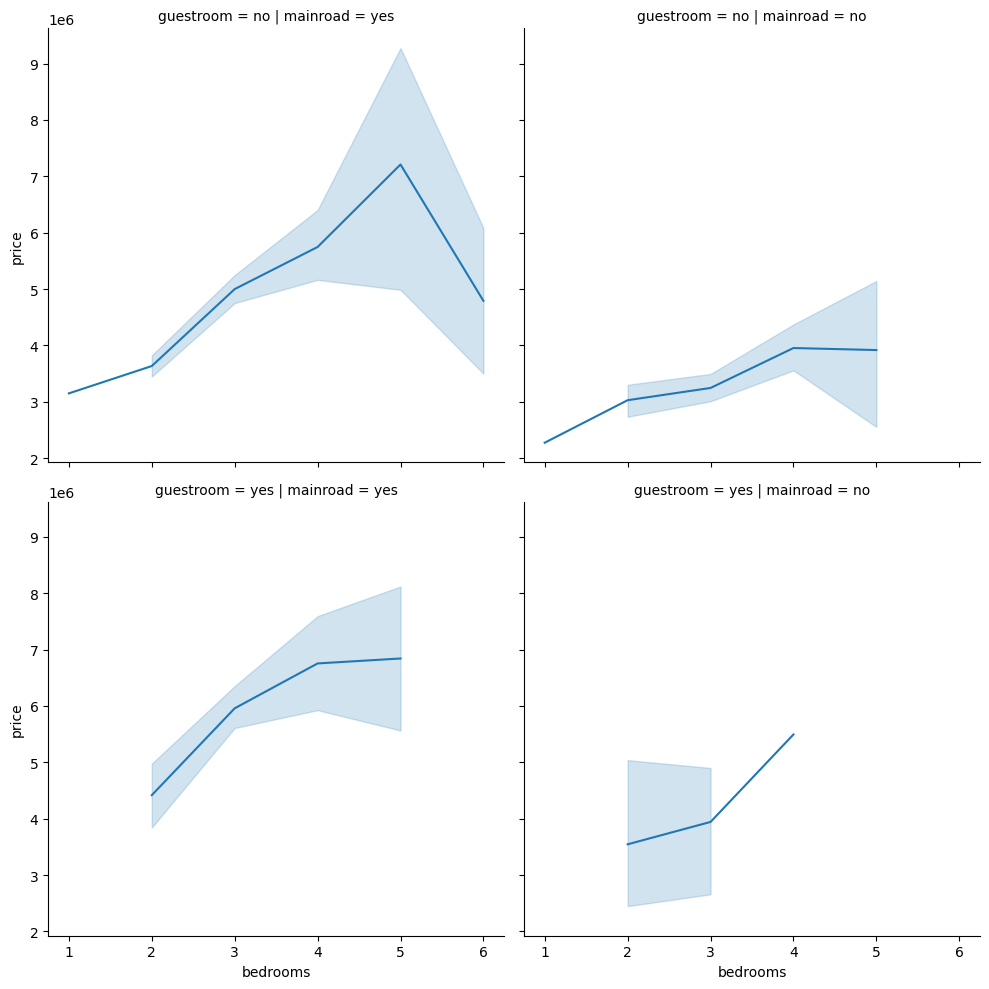

In [38]:
sns.lineplot(df, x='bedrooms', y ='price', hue='guestroom', style='mainroad')
plt.show()
sns.scatterplot(df, x='bedrooms', y ='price', hue='guestroom', style='mainroad')
plt.show()
sns.relplot(df, x='bedrooms', y ='price', hue='guestroom', col='mainroad', kind='line')
plt.show()
sns.relplot(df, x='bedrooms', y ='price', row='guestroom', col='mainroad', kind='line')
plt.show()

## Task 3: Distribution Plots
For a numerical column:
1. Plot Histogram using Seaborn.
2. Plot KDE plot.
3. Plot Rug plot.
4. Combine Histogram + KDE in a single plot.

Uses
1. Find outliers
2. Check distribution - Normal/skewed
3. Central tendency


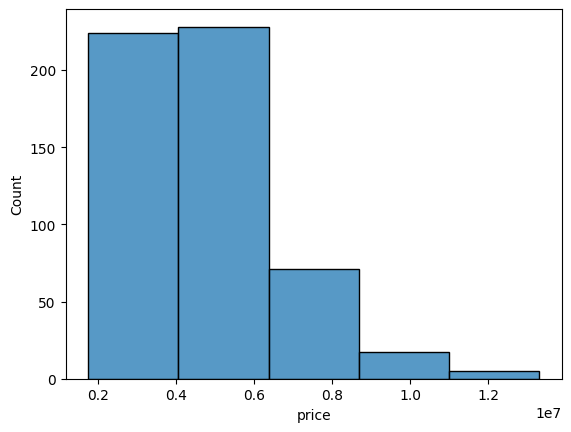

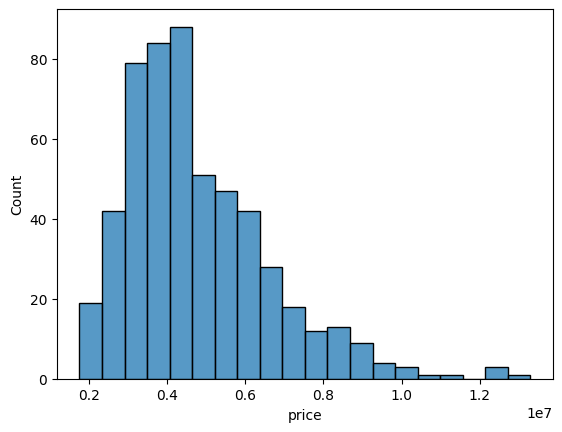

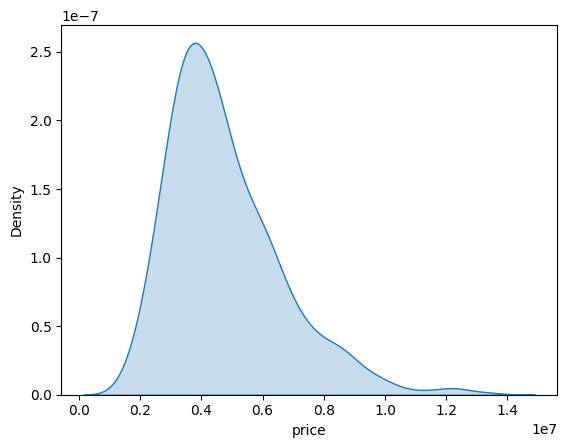

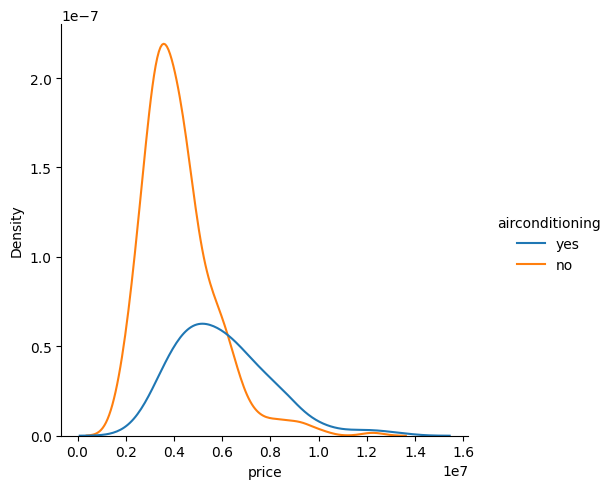

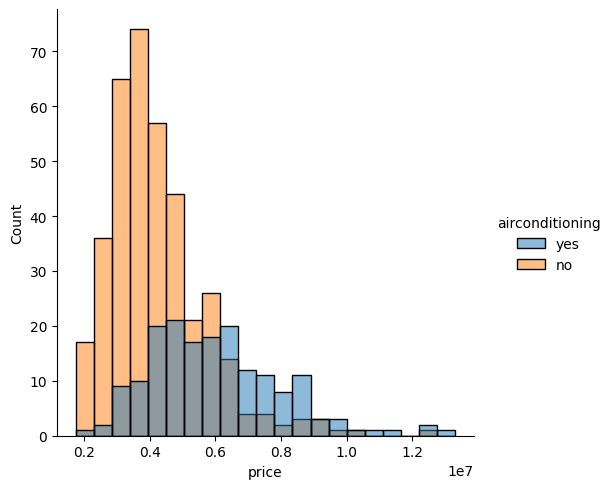

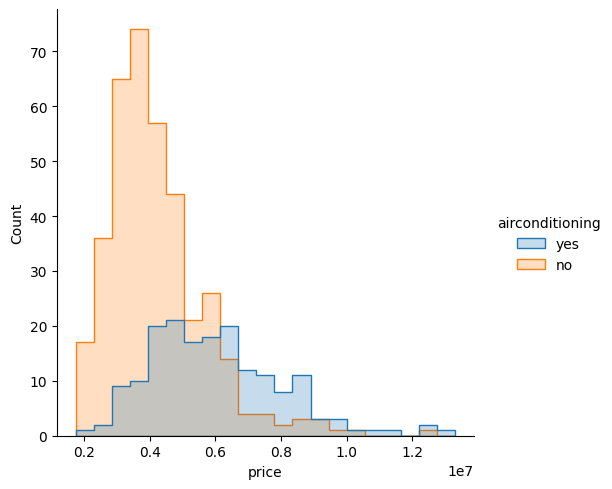

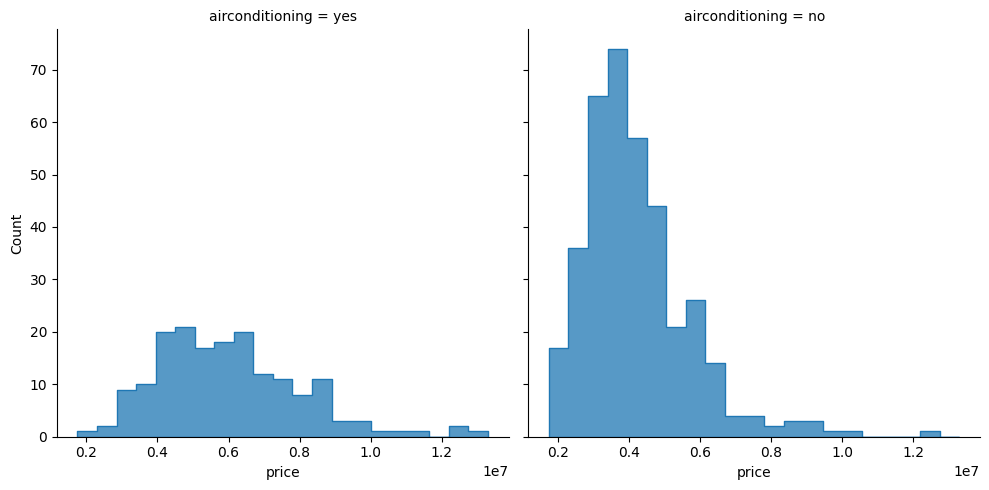

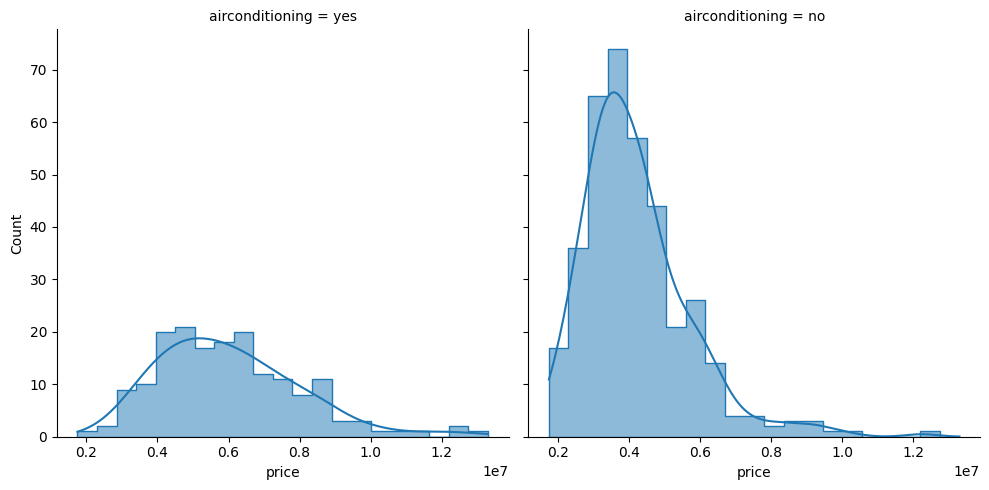

In [39]:
sns.histplot(df['price'], bins=5)
plt.show()
sns.histplot(df['price'], bins=20)
plt.show()
sns.kdeplot(df, x='price', fill=True)
plt.show()
sns.displot(df, x='price', kind='kde', hue='airconditioning')
plt.show()
sns.displot(df, x='price', kind='hist', hue='airconditioning')
plt.show()
sns.displot(df, x='price', kind='hist', hue='airconditioning', element='step')
plt.show()
sns.displot(df, x='price', kind='hist', col='airconditioning', element='step')
plt.show()
sns.displot(df, x='price', kind='hist', col='airconditioning', element='step', kde=True)
plt.show()

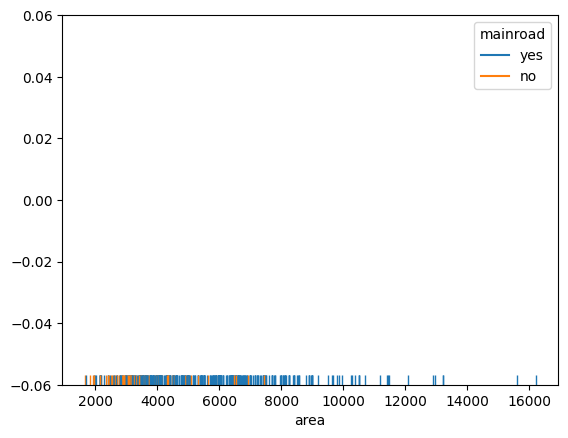

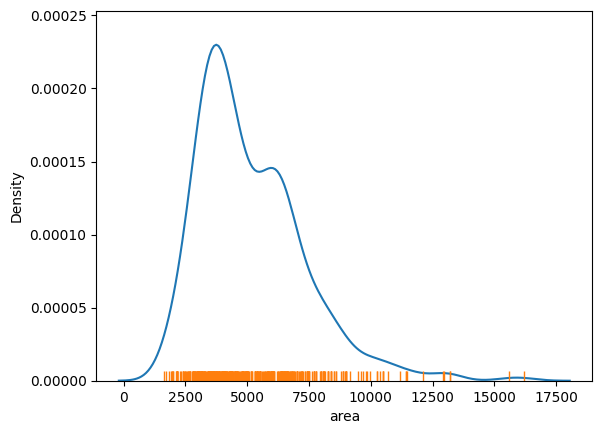

In [40]:
sns.rugplot(df, x='area' , hue='mainroad')
plt.show()

sns.kdeplot(df, x='area')
sns.rugplot(df, x='area')
plt.show()


## Task 4: Bivariate Distribution Plots
Using two numerical columns:
1. Create a bivariate histogram.
2. Create a bivariate KDE plot.

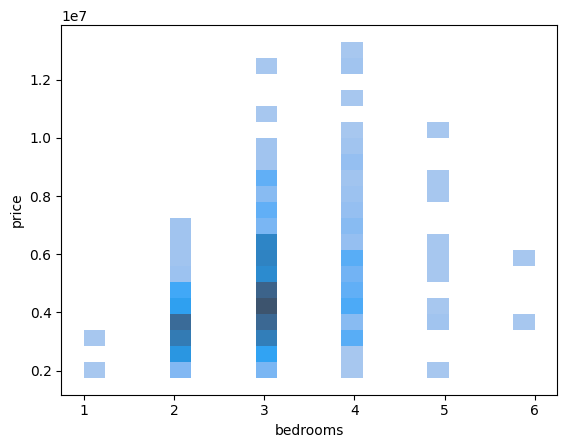

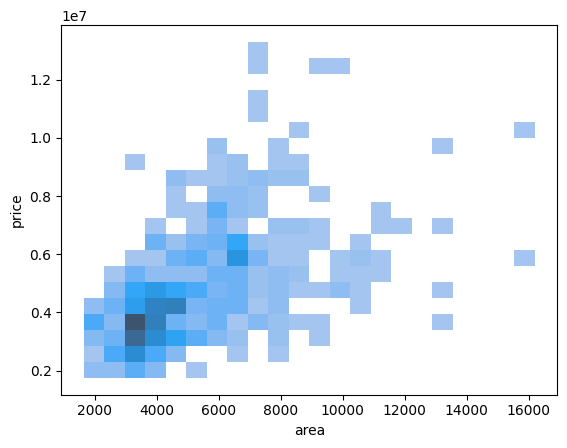

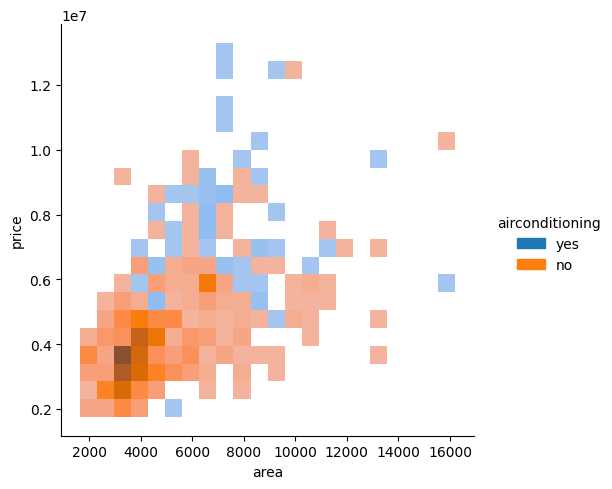

In [41]:
sns.histplot(data=df, y='price', x='bedrooms')
plt.show()

sns.histplot(data=df, y='price', x='area')
plt.show()

sns.displot(data=df, y='price', x='area', kind='hist', hue='airconditioning')
plt.show()

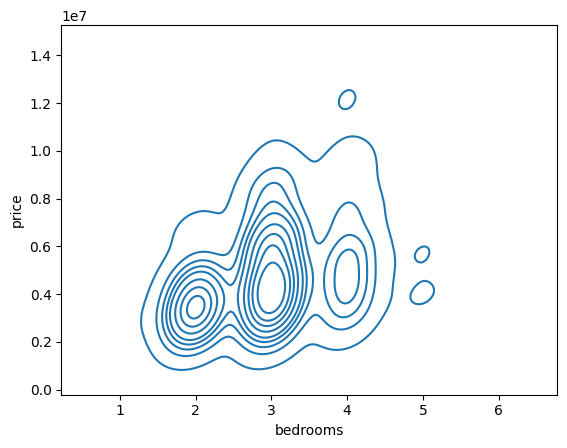

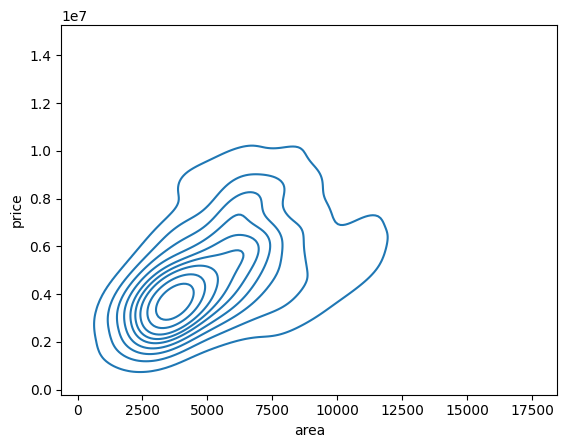

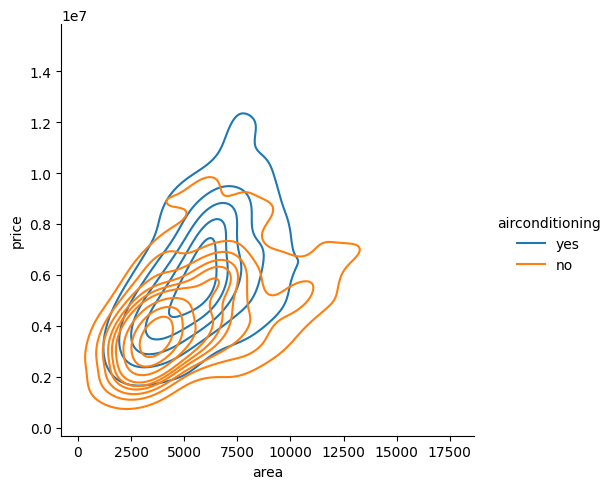

In [42]:
sns.kdeplot(data=df, y='price', x='bedrooms')
plt.show()

sns.kdeplot(data=df, y='price', x='area')
plt.show()

sns.displot(data=df, y='price', x='area', kind='kde', hue='airconditioning')
plt.show()

## Task 5: Matrix Plots
1. Create a pair plot using sns.pairplot().
2. Create a heatmap of correlation matrix.

- Shows relationship between 2 variables/dimensions like a table
- Corelation, missing data, comparison, density
- It works on data pivot
- heatmap() 
    - data - matrix
    - annot - show numbers
    - cmap - specific styling (coolwarm, viridis)

ClusterMap - Combo of heatmap and auto clustering
- groups similar rows and cols with internally working algo
- helps to find hidden patterns

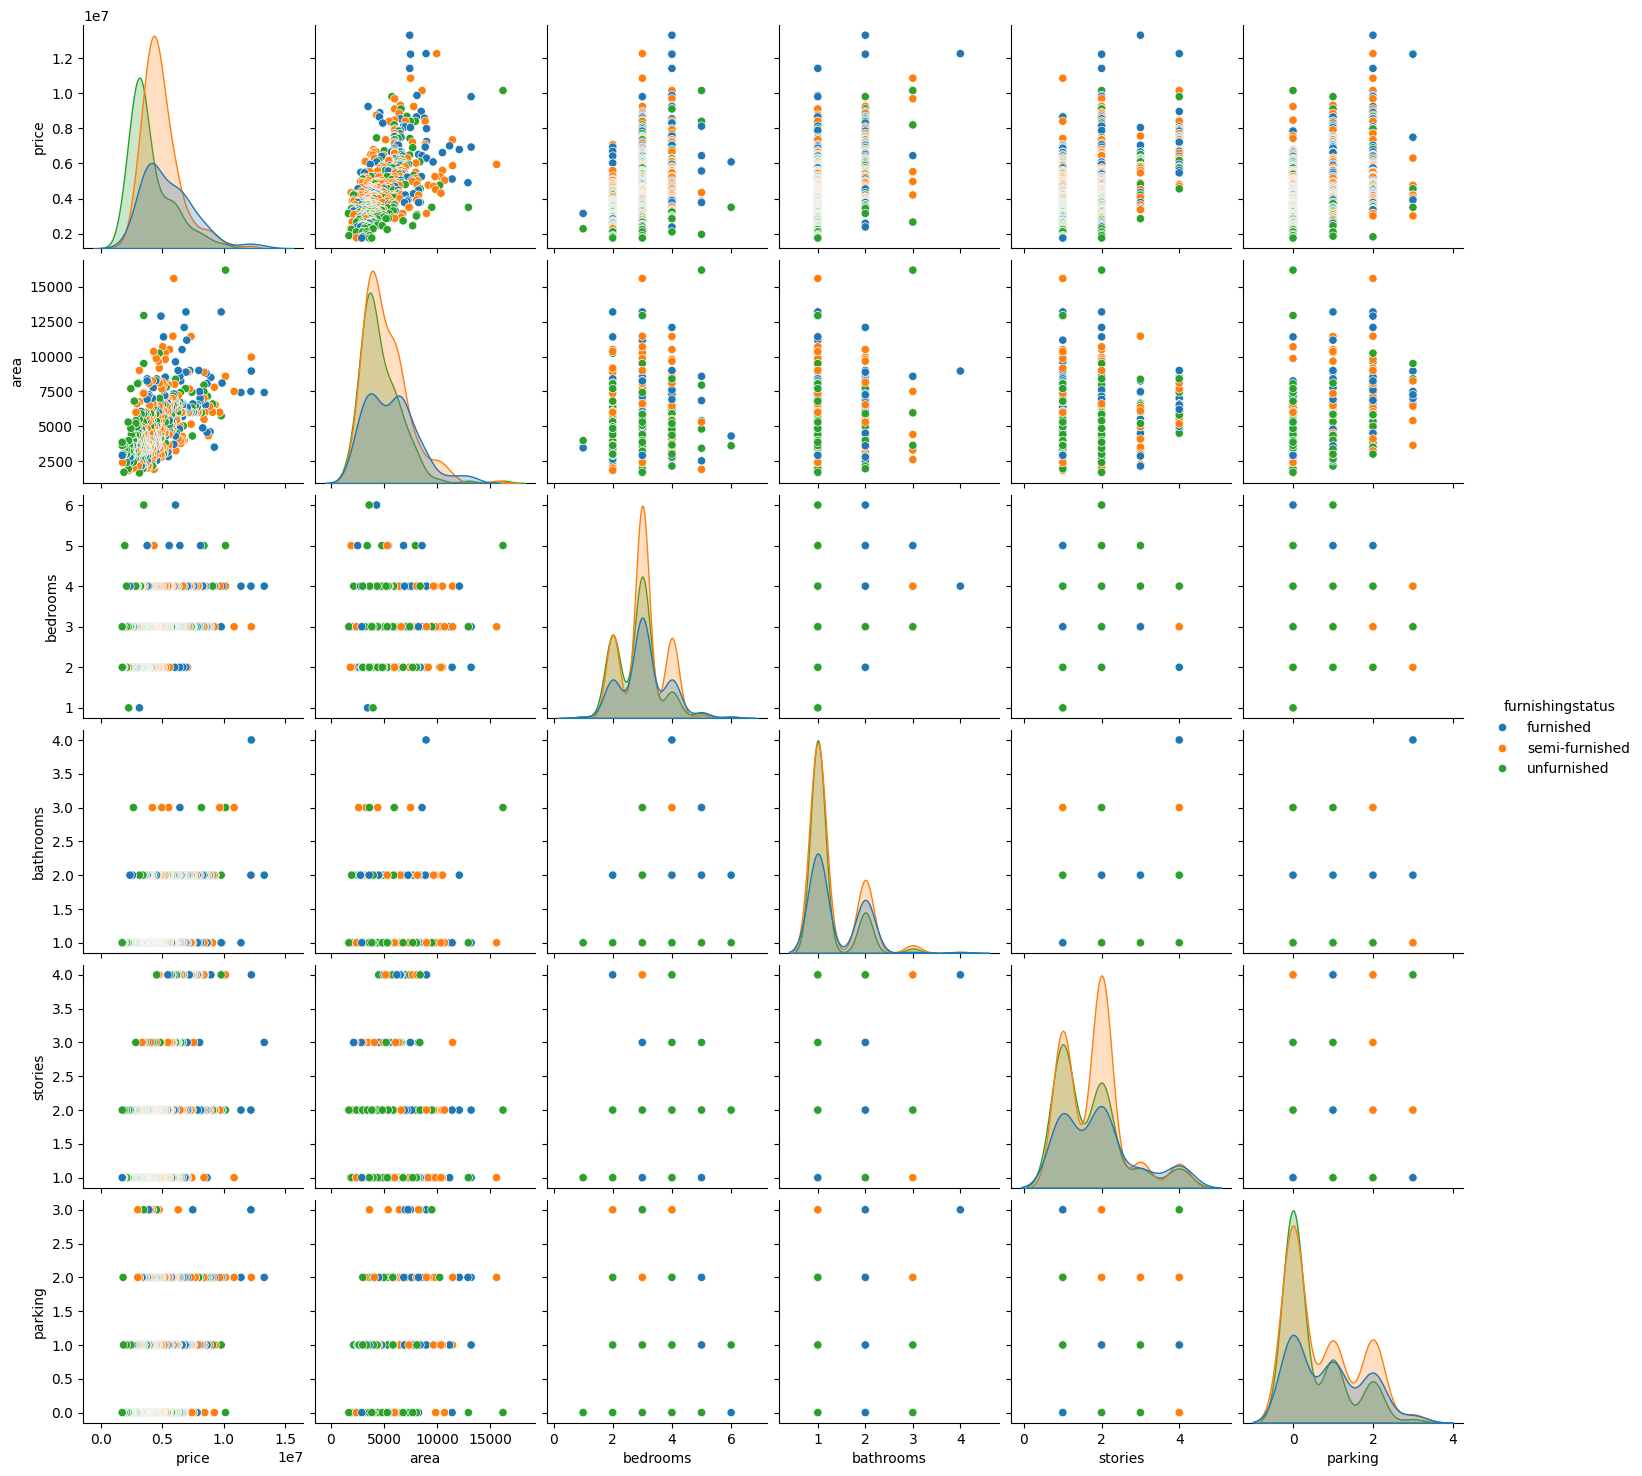

In [43]:
sns.pairplot(df, hue='furnishingstatus')
plt.show()

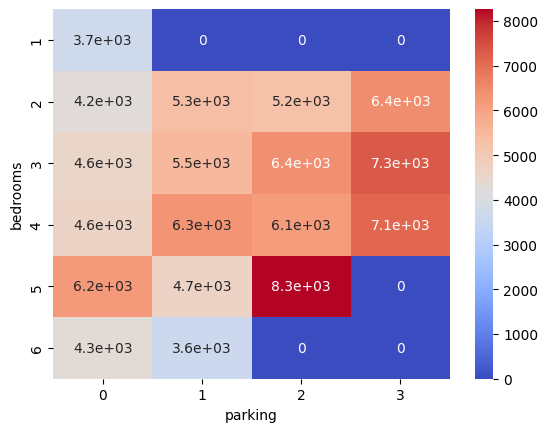

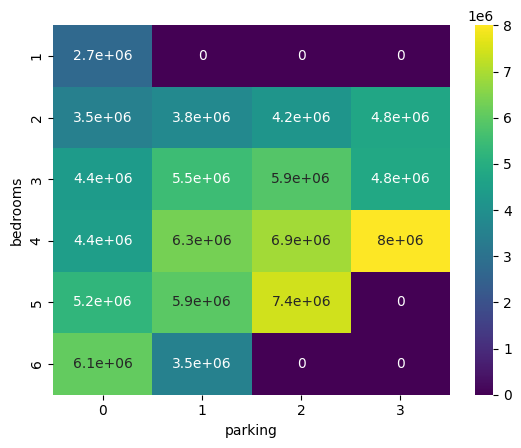

In [44]:
df_piv = df.pivot_table(index='bedrooms' , values='area', columns='parking', fill_value=0)
sns.heatmap(df_piv, annot=True, cmap='coolwarm')
plt.show()

df_piv = df.pivot_table(index='bedrooms' , values='price', columns='parking', fill_value=0)
sns.heatmap(df_piv, annot=True, cmap='viridis')
plt.show()

## Task 6: Categorical Plots
Using a categorical and numerical column:
1. Bar plot
2. Box plot
3. Violin plot
4. Count plot
Visualize realtionship where atleast 1 variable is categorical
x axis category, y axis numerical


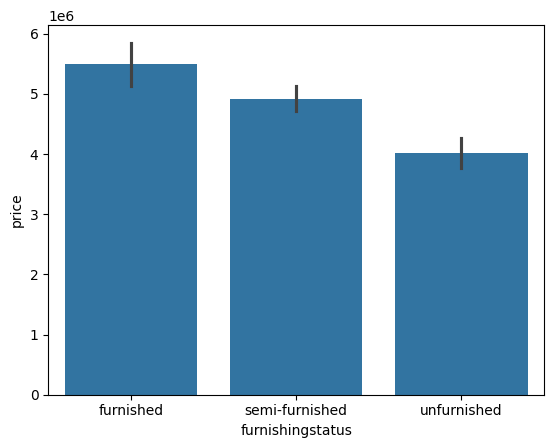

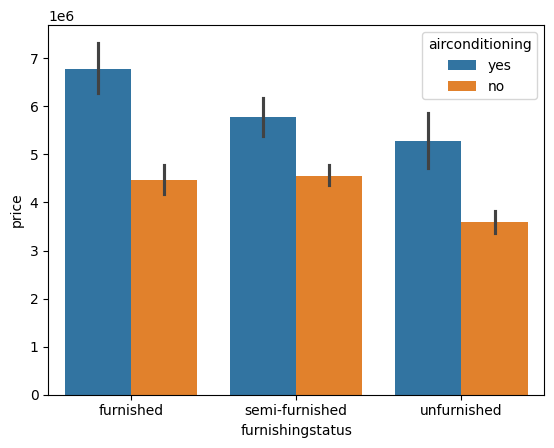

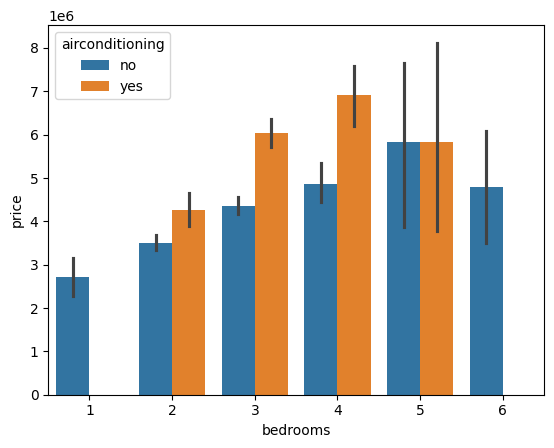

In [45]:
sns.barplot(data=df, x='furnishingstatus', y='price')
plt.show()

sns.barplot(data=df, x='furnishingstatus', y='price', hue='airconditioning')
plt.show()

sns.barplot(data=df, x='bedrooms', y='price', hue='airconditioning')
plt.show()

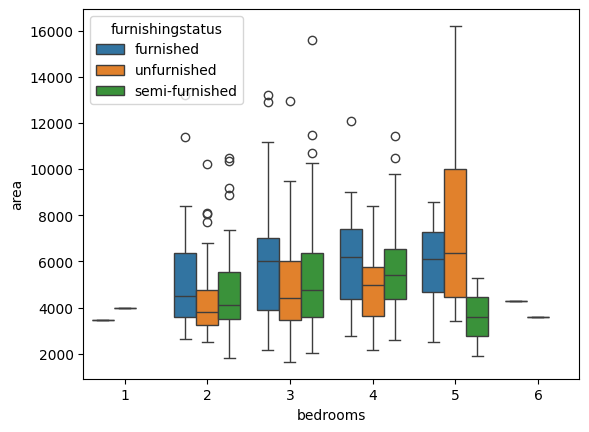

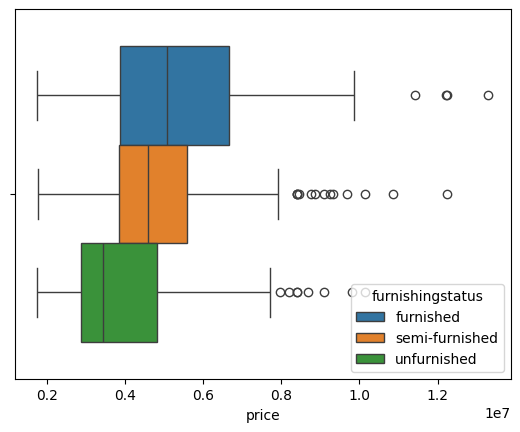

In [46]:
# Box plot - Check outliers and percentile
sns.boxplot(data=df, x='bedrooms', y='area', hue='furnishingstatus')
plt.show()

sns.boxplot(data=df, x='price', hue='furnishingstatus')
plt.show()

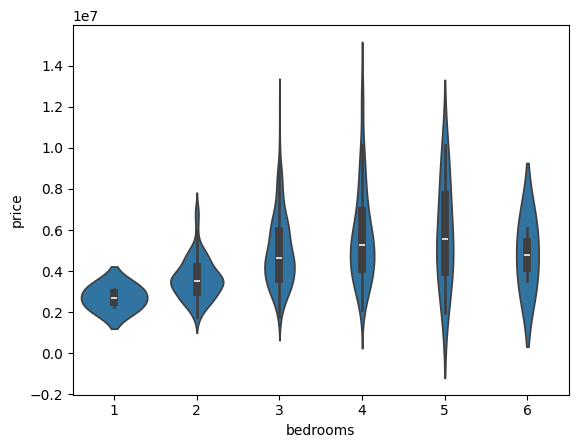

In [47]:
# Violin plot - combo of box plot and kde plot
sns.violinplot(data=df, x='bedrooms', y='price')
plt.show()

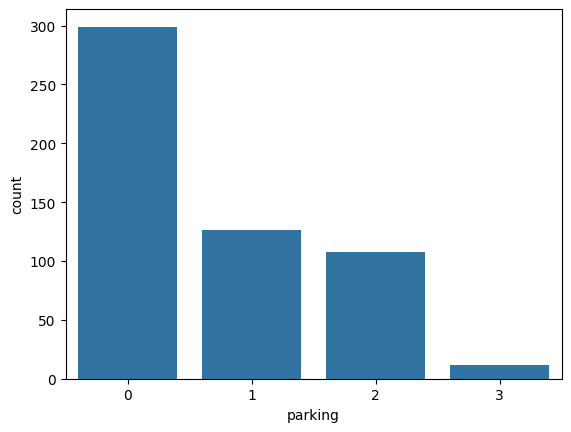

In [48]:
# count plot - distribution of categorical data
sns.countplot(data=df, x='parking')
plt.show()

## Task 7: Regression Plots
1. Create a regression plot (regplot) between two numerical columns.
2. Create an lmplot with hue using a categorical column.

- Relationship between 2 numerical variables (X and Y) along with best fit 

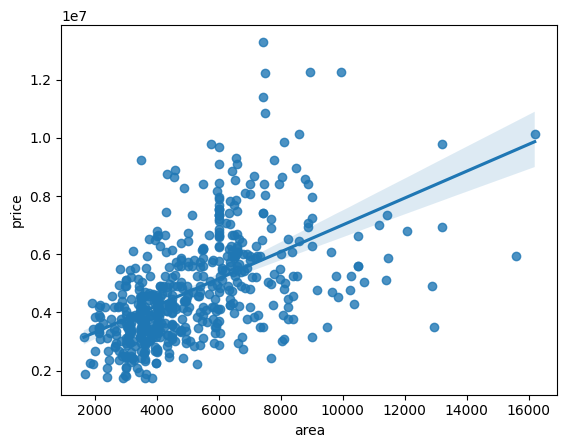

In [49]:
sns.regplot(data=df, x='area', y='price' )
plt.show()

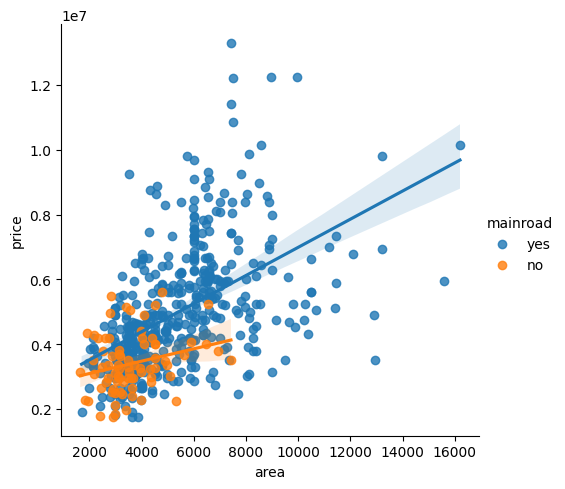

In [50]:
sns.lmplot(data=df, x='area', y='price', hue='mainroad' )
plt.show()

## Task 8: Multi-Plots & Figure-Level Plots
1. Create a FacetGrid with:
o One numerical variable on x-axis
o One numerical variable on y-axis
o Categorical column as col or row
2. Create a multi-plot dashboard using:
o relplot
o catplot
o displot

Multiplot shows combination of multiple plots together to analyse the relationship b/w variables in the similar way
Joint plot - combo of histogram and scatter plot, Distribution of multiple numerical cols

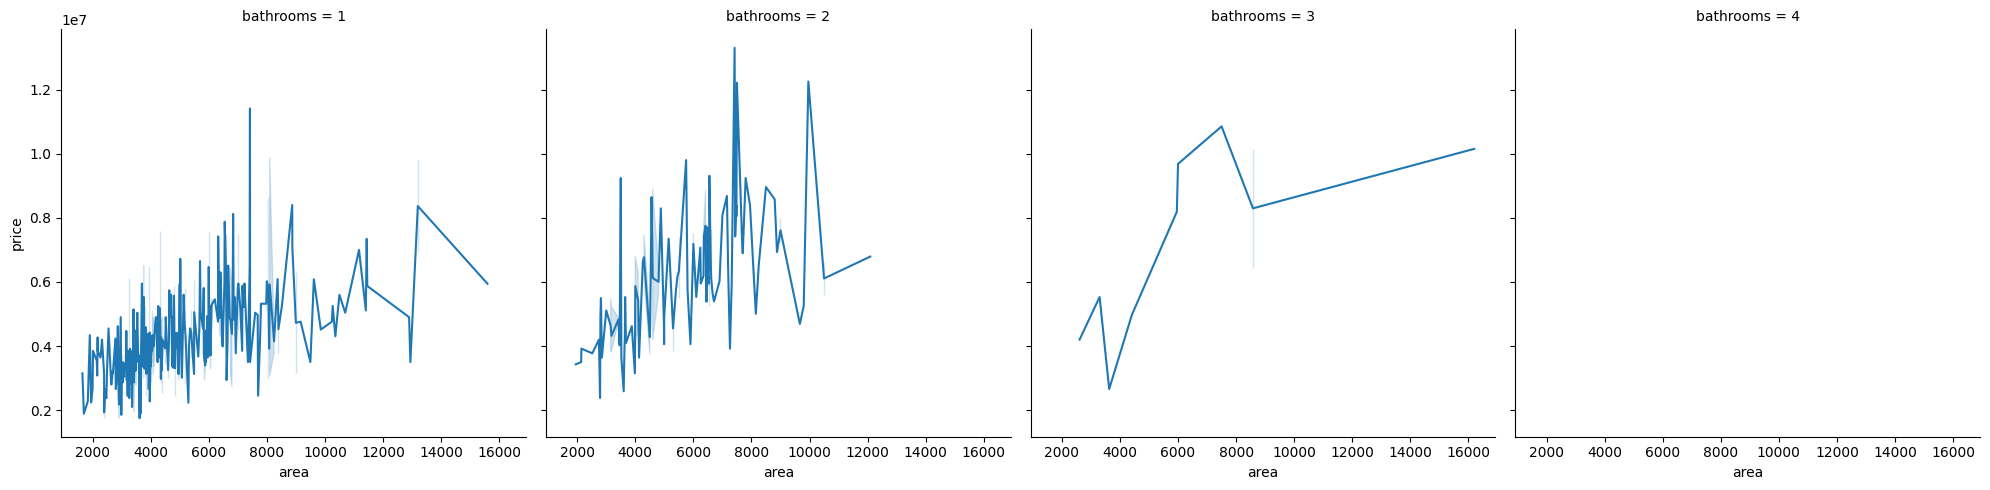

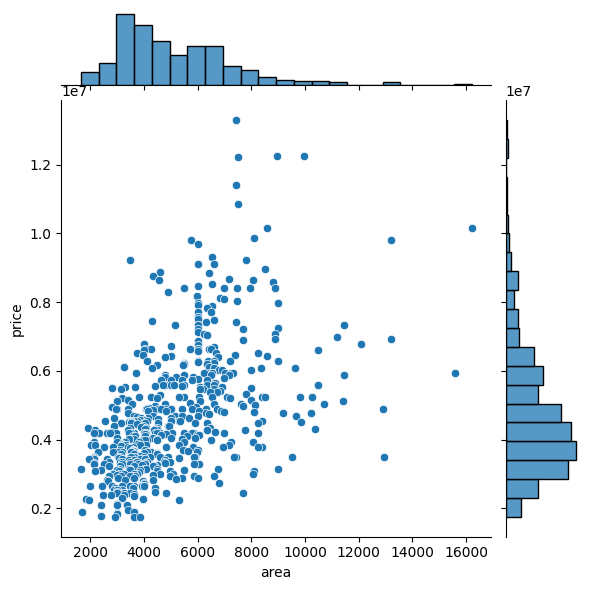

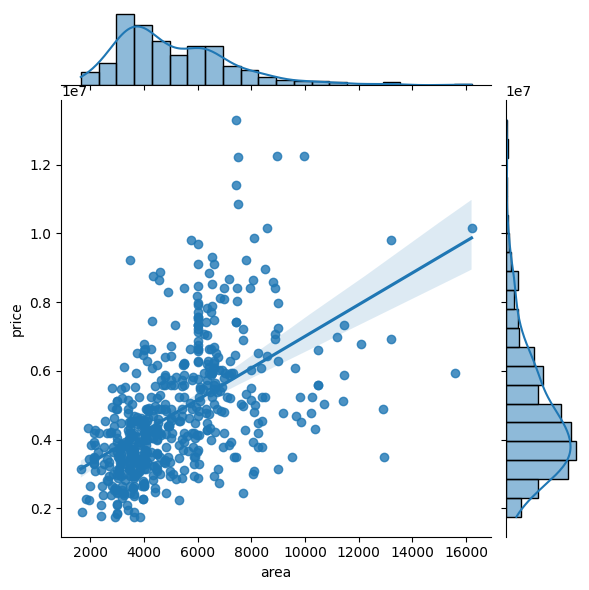

In [54]:
sns.relplot(df, x='area', y='price', col='bathrooms', kind='line')
plt.show()

sns.jointplot(df, x='area', y='price')
plt.show()

sns.jointplot(df, x='area', y='price', kind='reg')
plt.show()

In [55]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

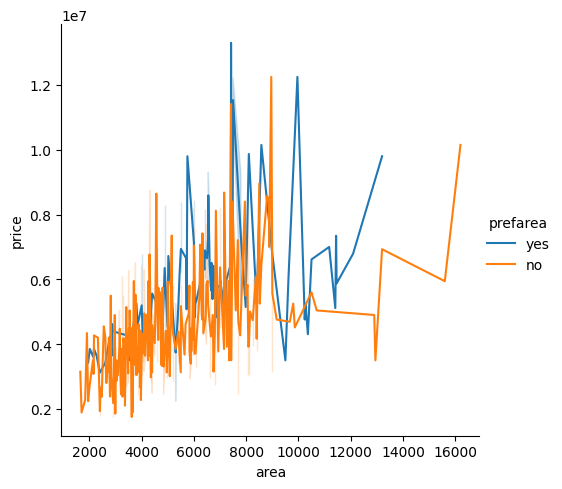

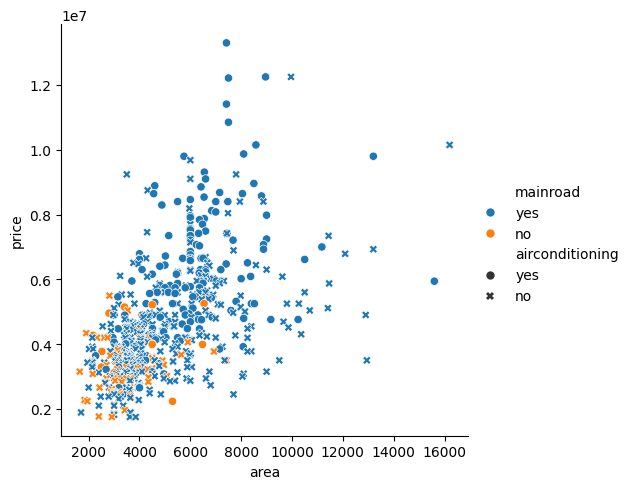

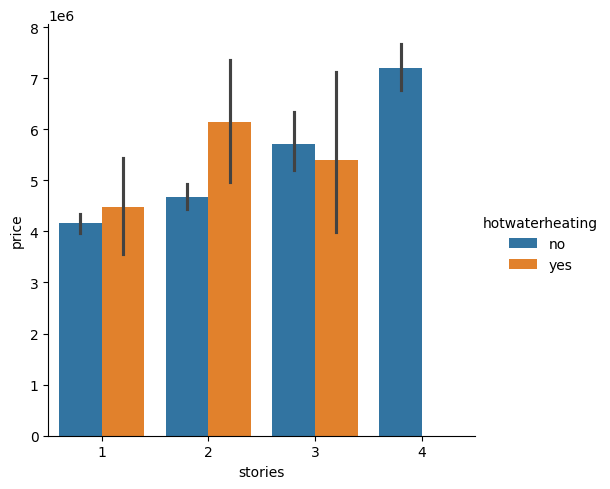

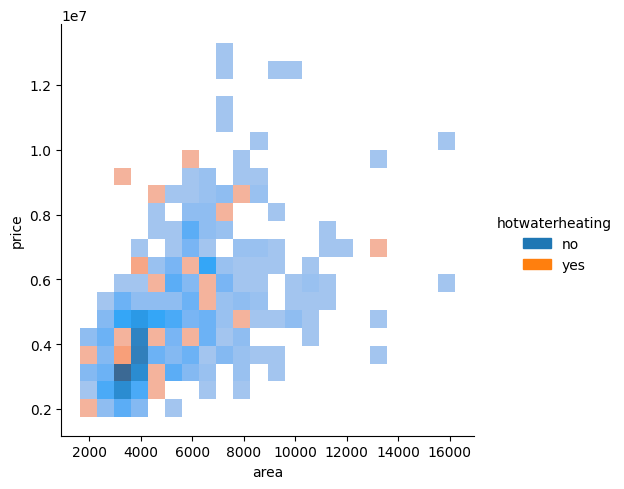

In [65]:
# multiplot dashboard
# relplot
sns.relplot(df, y='price', x='area', hue='prefarea', kind='line')
plt.show()

sns.relplot(df, y='price', x='area', hue='mainroad', style='airconditioning', kind='scatter')
plt.show()

# catplot
sns.catplot(df, x='stories', y='price', hue='hotwaterheating', kind='bar')
plt.show()

# displot
sns.displot(df, x='area', y='price', hue='hotwaterheating', kind='hist')
plt.show()